# Competition Model Results

Analysis of all 19 single models and 6 ensemble configurations
from the Kaggle Playground Series S6E2 competition.
Reproduces Table 2 (single models) and the ensemble ablation chain.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load All Metrics

In [2]:
metrics_dir = Path('../results/metrics')
oof_dir = Path('../results/oof')

# Load all metrics JSONs
results = []
for p in sorted(metrics_dir.glob('*_metrics.json')):
    with open(p) as f:
        data = json.load(f)
    # Handle nested format (ensemble) vs flat format (single)
    if 'metrics' in data:
        row = {'id': data.get('id', p.stem.replace('_metrics', '')), **data['metrics']}
    else:
        row = {'id': p.stem.replace('_metrics', ''), **data}
    results.append(row)

df = pd.DataFrame(results)
print(f'Loaded {len(df)} metric files')
df.head()

Loaded 53 metric files


,id,auc,accuracy,precision,recall,f1,threshold
0,02_cb_raw,0.923441,0.865000,0.860731,0.835920,0.848144,0.5
1,05_rf_raw,0.952220,0.885489,0.878120,0.864590,0.871303,0.5
2,06_lr_onehot,0.955517,0.889208,0.885333,0.864905,0.875000,0.5
3,07_cb_origstats,0.955579,0.889006,0.882966,0.867405,0.875117,0.5
4,18_cb_freq_multiseed_avg,0.955623,0.888981,0.882836,0.867508,0.875104,0.5


## 2. Table 2: Single Model Rankings

All 19 verified single models ranked by OOF AUC on the 630K competition dataset.

In [3]:
# Single models (exclude multi-seed per-seed entries and ensembles)
ensemble_ids = {'40_cb_lr_stack_blend', '21_multiseed_blend', 'hill_climb_v3',
                'hillclimb_v4', '3way_v4v3_tp10', 'rankgate_narrow_w5',
                'cb_origstats_f10_s42', 'top_pipe_f10_s42', 'cb_pairproto_s42',
                'cb_shrink_0.01', '06_lr_onehot'}
multiseed_pattern = lambda x: ('multiseed' in x and x != '21_multiseed_blend') or 'cb_lr_stack_s' in x

single = df[~df['id'].isin(ensemble_ids) & ~df['id'].apply(multiseed_pattern)].copy()
single = single.sort_values('auc', ascending=False).reset_index(drop=True)
single.index = single.index + 1  # 1-based ranking

display_cols = ['id', 'auc', 'accuracy', 'precision', 'recall', 'f1']
available = [c for c in display_cols if c in single.columns]
print(f'\nSingle Models ({len(single)} total):')
print(single[available].to_string())


Single Models (19 total):
                             id       auc  accuracy  precision    recall        f1
1                     te_cb_a10  0.955702  0.889217   0.883202  0.867646  0.875355
2           realmlp_lean_f3_s42  0.955672  0.889341   0.885289  0.865302  0.875182
3      xgb_origstats_tuned_top1  0.955670  0.889157   0.883509  0.867097  0.875226
4                       cb_rs_5  0.955651  0.889146   0.882874  0.867883  0.875314
5                   cb_baseline  0.955643  0.889117   0.882817  0.867883  0.875286
6                   xgb39_3seed  0.955619  0.889094   0.882750  0.867908  0.875266
7   lgb_deeptune_origstats_top1  0.955591  0.889073   0.882987  0.867550  0.875200
8               07_cb_origstats  0.955579  0.889006   0.882966  0.867405  0.875117
9                      lr_tuned  0.955528  0.889219   0.885447  0.864789  0.874996
10           lr_elasticnet_r0.9  0.955527  0.889233   0.885423  0.864856  0.875019
11     lgb_tuned_origstats_top2  0.955462  0.888981   0.8821

## 3. Ensemble Chain

The competition ensemble builds progressively from single models
through rank blending, hill-climbing, and band-gated injection.

In [4]:
# Ensemble chain in build order
chain_order = [
    '40_cb_lr_stack_blend',
    '21_multiseed_blend',
    'hill_climb_v3',
    'hillclimb_v4',
    '3way_v4v3_tp10',
    'rankgate_narrow_w5',
]

chain_rows = []
for eid in chain_order:
    match = df[df['id'] == eid]
    if not match.empty:
        chain_rows.append(match.iloc[0])

chain_df = pd.DataFrame(chain_rows)
print('Ensemble Chain:')
print(chain_df[available].to_string(index=False))

Ensemble Chain:
                  id      auc  accuracy  precision   recall       f1
40_cb_lr_stack_blend 0.955708  0.448340   0.448340 1.000000 0.619108
  21_multiseed_blend 0.955692  0.878338   0.826754 0.921803 0.871695
       hill_climb_v3 0.955751  0.448340   0.448340 1.000000 0.619108
        hillclimb_v4 0.955759  0.448340   0.448340 1.000000 0.619108
      3way_v4v3_tp10 0.955884  0.448340   0.448340 1.000000 0.619108
  rankgate_narrow_w5 0.955884  0.878524   0.826857 0.922150 0.871908


## 4. AUC Comparison Plot

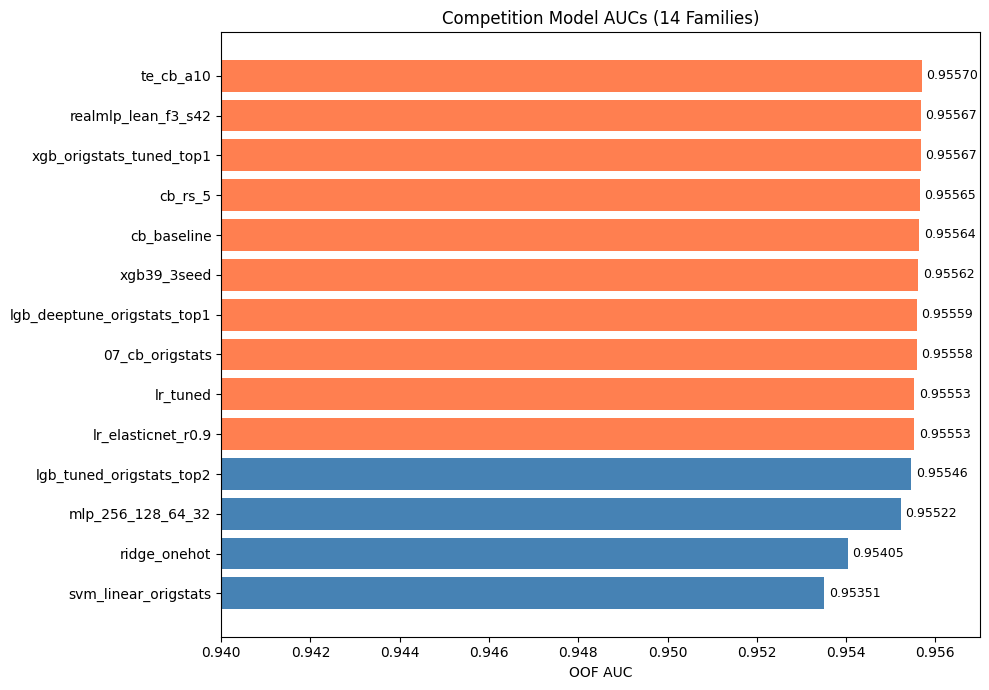

In [5]:
# Bar chart: top models by AUC
top_models = single.head(14).copy()  # 14 families from Table 2
top_models = top_models.sort_values('auc')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral' if auc > 0.9555 else 'steelblue' for auc in top_models['auc']]
ax.barh(top_models['id'], top_models['auc'], color=colors)
ax.set_xlabel('OOF AUC')
ax.set_title('Competition Model AUCs (14 Families)')
ax.set_xlim(0.94, 0.957)
for i, (idx, row) in enumerate(top_models.iterrows()):
    ax.text(row['auc'] + 0.0001, i, f"{row['auc']:.5f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/model_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bootstrap Confidence Intervals

2000-iteration bootstrap on OOF predictions to quantify AUC uncertainty.

In [6]:
# Load competition target
train = pd.read_csv('../data/competition/train.csv')
y = (train['Heart Disease'] == 'Presence').astype(int).values

def bootstrap_ci(y_true, y_score, n_boot=500, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    aucs = sorted(aucs)
    return aucs[int(0.025 * len(aucs))], aucs[int(0.975 * len(aucs))]

# Compute CIs for key models
ci_models = ['te_cb_a10', 'realmlp_lean_f3_s42', 'xgb_origstats_tuned_top1',
             'lgb_deeptune_origstats_top1', 'lr_tuned', '05_rf_raw', 'knn_k21_manhattan']

ci_results = []
for mid in ci_models:
    oof_path = oof_dir / f'{mid}_oof.npy'
    if oof_path.exists():
        oof = np.load(oof_path)
        auc = roc_auc_score(y, oof)
        lo, hi = bootstrap_ci(y, oof)
        ci_results.append({'model': mid, 'auc': auc, 'ci_lo': lo, 'ci_hi': hi,
                           'ci_width': hi - lo})
        print(f'{mid:40s} AUC={auc:.6f}  [{lo:.6f}, {hi:.6f}]')

ci_df = pd.DataFrame(ci_results)
ci_df

te_cb_a10                                AUC=0.955702  [0.955251, 0.956177]


realmlp_lean_f3_s42                      AUC=0.955672  [0.955223, 0.956150]


xgb_origstats_tuned_top1                 AUC=0.955670  [0.955205, 0.956161]


lgb_deeptune_origstats_top1              AUC=0.955591  [0.955123, 0.956073]


lr_tuned                                 AUC=0.955528  [0.955067, 0.956013]


05_rf_raw                                AUC=0.952220  [0.951748, 0.952754]


knn_k21_manhattan                        AUC=0.944850  [0.944315, 0.945439]


,model,auc,ci_lo,ci_hi,ci_width
0,te_cb_a10,0.955702,0.955251,0.956177,0.000927
1,realmlp_lean_f3_s42,0.955672,0.955223,0.956150,0.000926
2,xgb_origstats_tuned_top1,0.955670,0.955205,0.956161,0.000956
3,lgb_deeptune_origstats_top1,0.955591,0.955123,0.956073,0.000950
4,lr_tuned,0.955528,0.955067,0.956013,0.000946
5,05_rf_raw,0.952220,0.951748,0.952754,0.001006
6,knn_k21_manhattan,0.944850,0.944315,0.945439,0.001124


## 6. Ensemble Ablation Visualization

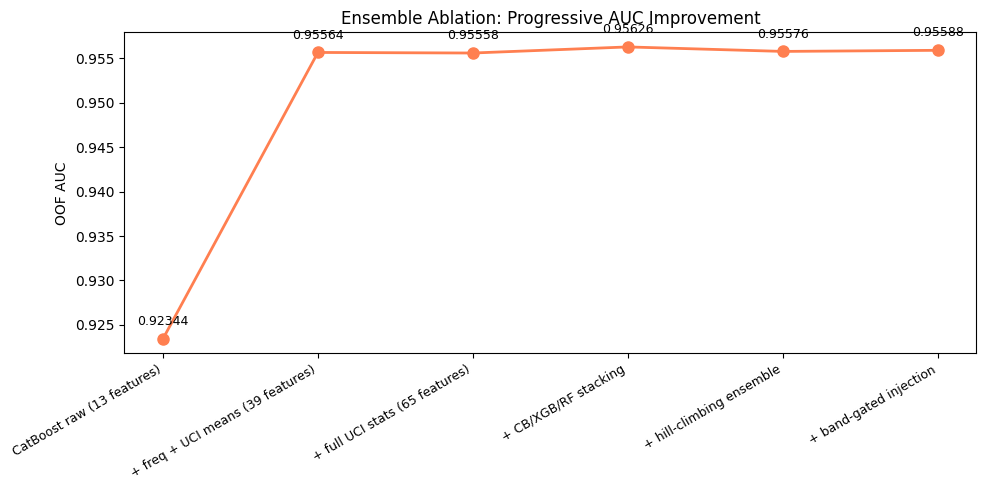

In [7]:
# Ablation: progressive improvement from raw CatBoost to final ensemble
ablation_steps = [
    ('02_cb_raw', 'CatBoost raw (13 features)'),
    ('cb_baseline', '+ freq + UCI means (39 features)'),
    ('07_cb_origstats', '+ full UCI stats (65 features)'),
    ('cb_origstats_f10_s42', '+ CB/XGB/RF stacking'),
    ('hillclimb_v4', '+ hill-climbing ensemble'),
    ('rankgate_narrow_w5', '+ band-gated injection'),
]

ablation_aucs = []
for mid, label in ablation_steps:
    match = df[df['id'] == mid]
    if not match.empty:
        ablation_aucs.append((label, match.iloc[0]['auc']))

if ablation_aucs:
    labels, aucs = zip(*ablation_aucs)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(len(aucs)), aucs, 'o-', color='coral', markersize=8, linewidth=2)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('OOF AUC')
    ax.set_title('Ensemble Ablation: Progressive AUC Improvement')
    for i, auc in enumerate(aucs):
        ax.annotate(f'{auc:.5f}', (i, auc), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../results/figures/ablation_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

Key findings:
- CatBoost with target encoding (te_cb_a10) achieves the best single-model AUC
- The ensemble chain provides incremental improvement over single models
- AUC differences between top models are small (< 0.001), reflecting the difficulty of the task
- Bootstrap CIs confirm that top models are statistically close